In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import seaborn as sns
import skimage
from skimage import color, data, restoration
import galsim

In [3]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/validation/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

### Noiseless data

In [27]:
images = np.load(root_dir_v1+'img_noiseless_sample_1.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_1.npy', mmap_mode = 'c')

In [28]:
images.shape, psf.shape

((8456, 59, 59, 6), (8456, 59, 59, 6))

In [29]:
images.shape[0]

8456

In [30]:
n_img = images.shape[0]
n_bands = 6
img_size = 59

dc2_fwhm = [1.0006281279794769+0.001, 0.9710792014976626+0.001, 0.9129482496447275+0.001, 0.8409696986788218+0.001, 0.9712788016914978+0.001, 1.2119174962744763+0.001]

#deconvolved_wiener = np.zeros((n_img,img_size,img_size,n_bands))
#deconvolved_galsim = np.zeros((n_img,img_size,img_size,n_bands))
reconvolved_galsim = np.zeros((n_img,img_size,img_size,n_bands))
for i in range(n_img):
    for j in range (n_bands):
        # GalSim deconvolution
        psf_image = galsim.Image(psf[i,:,:,j], copy=True)
        galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
        inv_psf = galsim.Deconvolve(galsim_psf)
        image_galsim = galsim.Image(images[i,:,:,j], copy=True)
        galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)
        deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)
        #image = galsim.ImageF(59, 59, scale=0.2)
        #_ = deconv_galsim_obj.drawImage(image=image)
        #deconvolved_galsim[i,:,:,j] = image.array.data
        
        PSF_lsst = galsim.Kolmogorov(fwhm=dc2_fwhm[j])
        # reconvolve by PSF
        reconv_galsim_obj = galsim.Convolve(PSF_lsst, deconv_galsim_obj)
        
        image = galsim.ImageF(59, 59, scale=0.2)
        _ = reconv_galsim_obj.drawImage(image=image)
        reconvolved_galsim[i,:,:,j] = image.array.data  
        
        # Wiener deconvolution
        #deconvolved_wiener[i,:,:,j] = restoration.deconvolution.wiener(images[i,:,:,j], psf[i,:,:,j], 0.15)


In [23]:
np.save(root_dir_v1+'img_noiseless_reconvolved_sample_1.npy', reconvolved_galsim)

In [24]:
test = np.load(root_dir_v1+'img_noiseless_reconvolved_sample_1.npy', mmap_mode = 'c')

In [25]:
test.shape

(8209, 59, 59, 6)

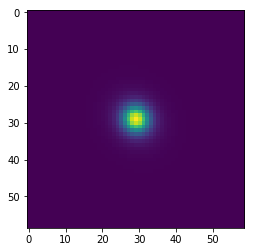

In [26]:
plt.imshow(reconvolved_galsim[0,:,:,0])

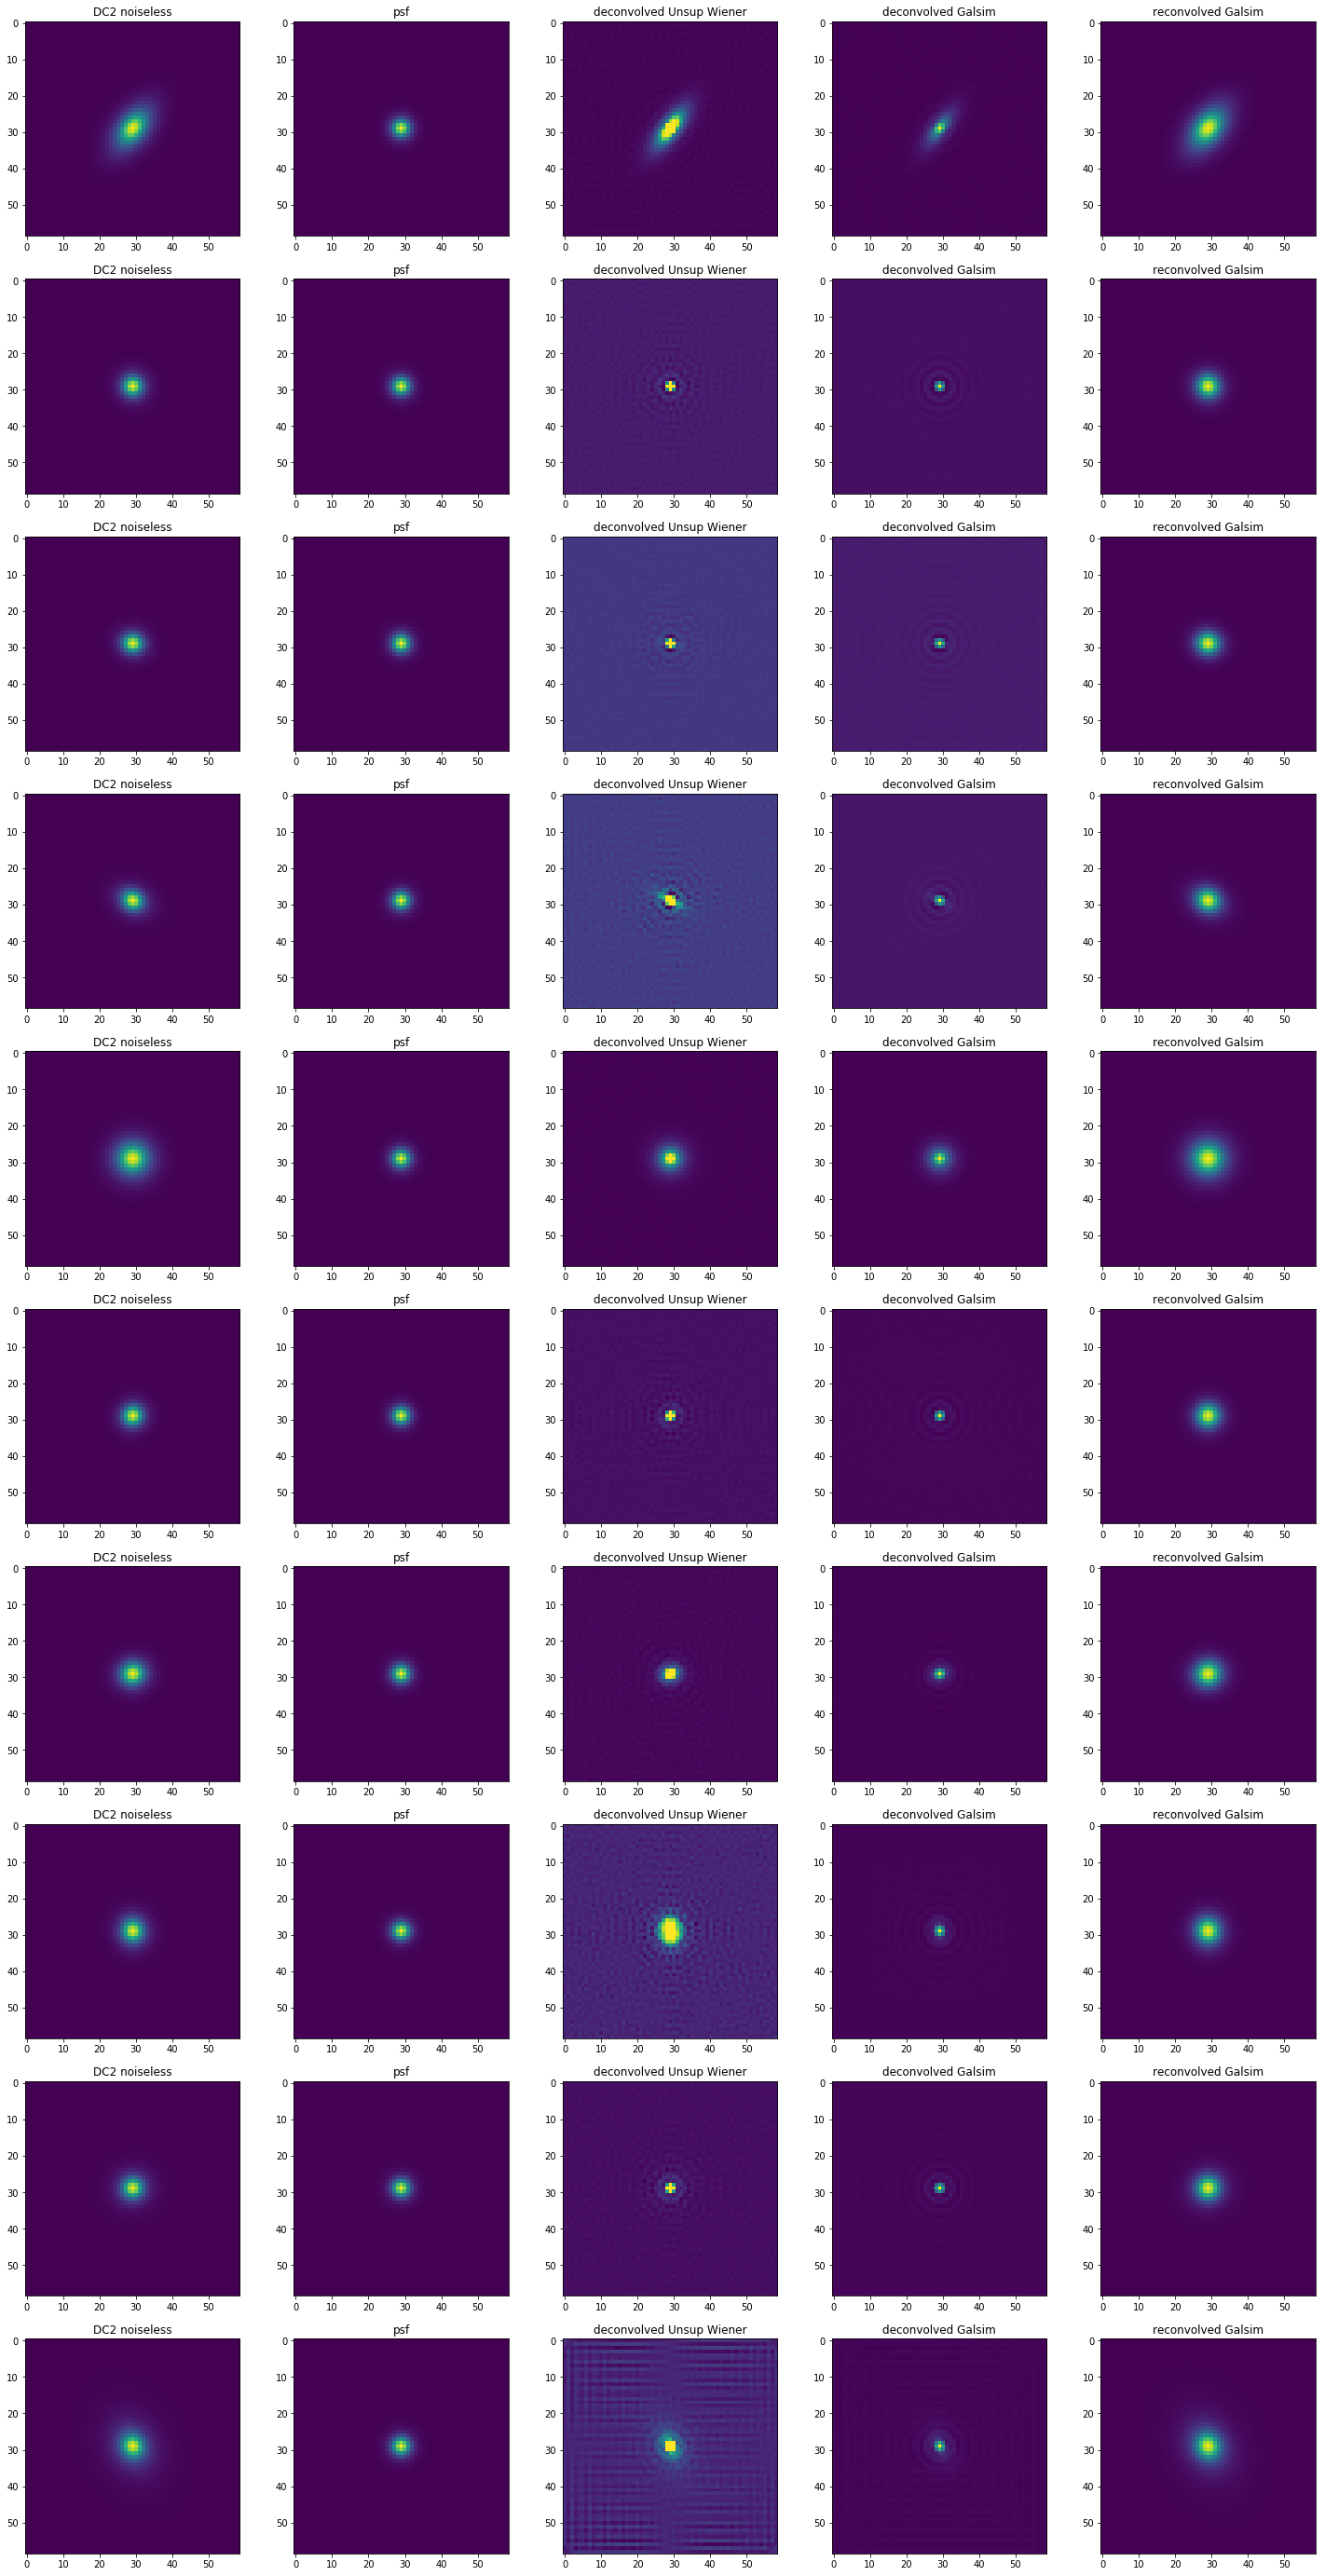

In [25]:
fig, axes = plt.subplots(10,5, figsize = (25,50))

for i in range(10):
    axes[i,0].imshow(images[i,:,:,2])
    axes[i,1].imshow(psf[i,:,:,2])
    axes[i,2].imshow(deconvolved_unsup_wiener[i,:,:,2])
    axes[i,3].imshow(deconvolved_galsim[i,:,:,2])
    axes[i,4].imshow(reconvolved_galsim[i,:,:,2])
    
    
    axes[i,0].set_title('DC2 noiseless')
    axes[i,1].set_title('psf')
    axes[i,2].set_title('deconvolved Unsup Wiener')
    axes[i,3].set_title('deconvolved Galsim')
    axes[i,4].set_title('reconvolved Galsim')

### Noisy data

In [34]:
images = np.load(root_dir_v1+'img_cropped_sample_1.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_1.npy', mmap_mode = 'c')

In [35]:
n_img = images.shape[0]
n_bands = 6
img_size = 59

dc2_fwhm = [1.0006281279794769+0.001, 0.9710792014976626+0.001, 0.9129482496447275+0.001, 0.8409696986788218+0.001, 0.9712788016914978+0.001, 1.2119174962744763+0.001]

deconvolved_wiener = np.zeros((n_img,img_size,img_size,n_bands))
#deconvolved_galsim = np.zeros((n_img,img_size,img_size,n_bands))
reconvolved_galsim = np.zeros((n_img,img_size,img_size,n_bands))
for i in range(n_img):
    for j in range (n_bands):
        # GalSim deconvolution
        psf_image = galsim.Image(psf[i,:,:,j], copy=True)
        galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
        inv_psf = galsim.Deconvolve(galsim_psf)
        image_galsim = galsim.Image(images[i,:,:,j], copy=True)
        galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)
        deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)
        #image = galsim.ImageF(59, 59, scale=0.2)
        #_ = deconv_galsim_obj.drawImage(image=image)
        #deconvolved_galsim[i,:,:,j] = image.array.data
       
        PSF_lsst = galsim.Kolmogorov(fwhm=dc2_fwhm[j])
        # recconvolve by PSF
        reconv_galsim_obj = galsim.Convolve(PSF_lsst, deconv_galsim_obj)
        
        image = galsim.ImageF(59, 59, scale=0.2)
        _ = reconv_galsim_obj.drawImage(image=image)
        reconvolved_galsim[i,:,:,j] = image.array.data
        
        # Wiener deconvolution
        #deconvolved_wiener[i,:,:,j] = restoration.deconvolution.wiener(images[i,:,:,j], psf[i,:,:,j], 0.15)

In [36]:
np.save(root_dir_v1+'img_reconvolved_sample_1.npy', reconvolved_galsim)

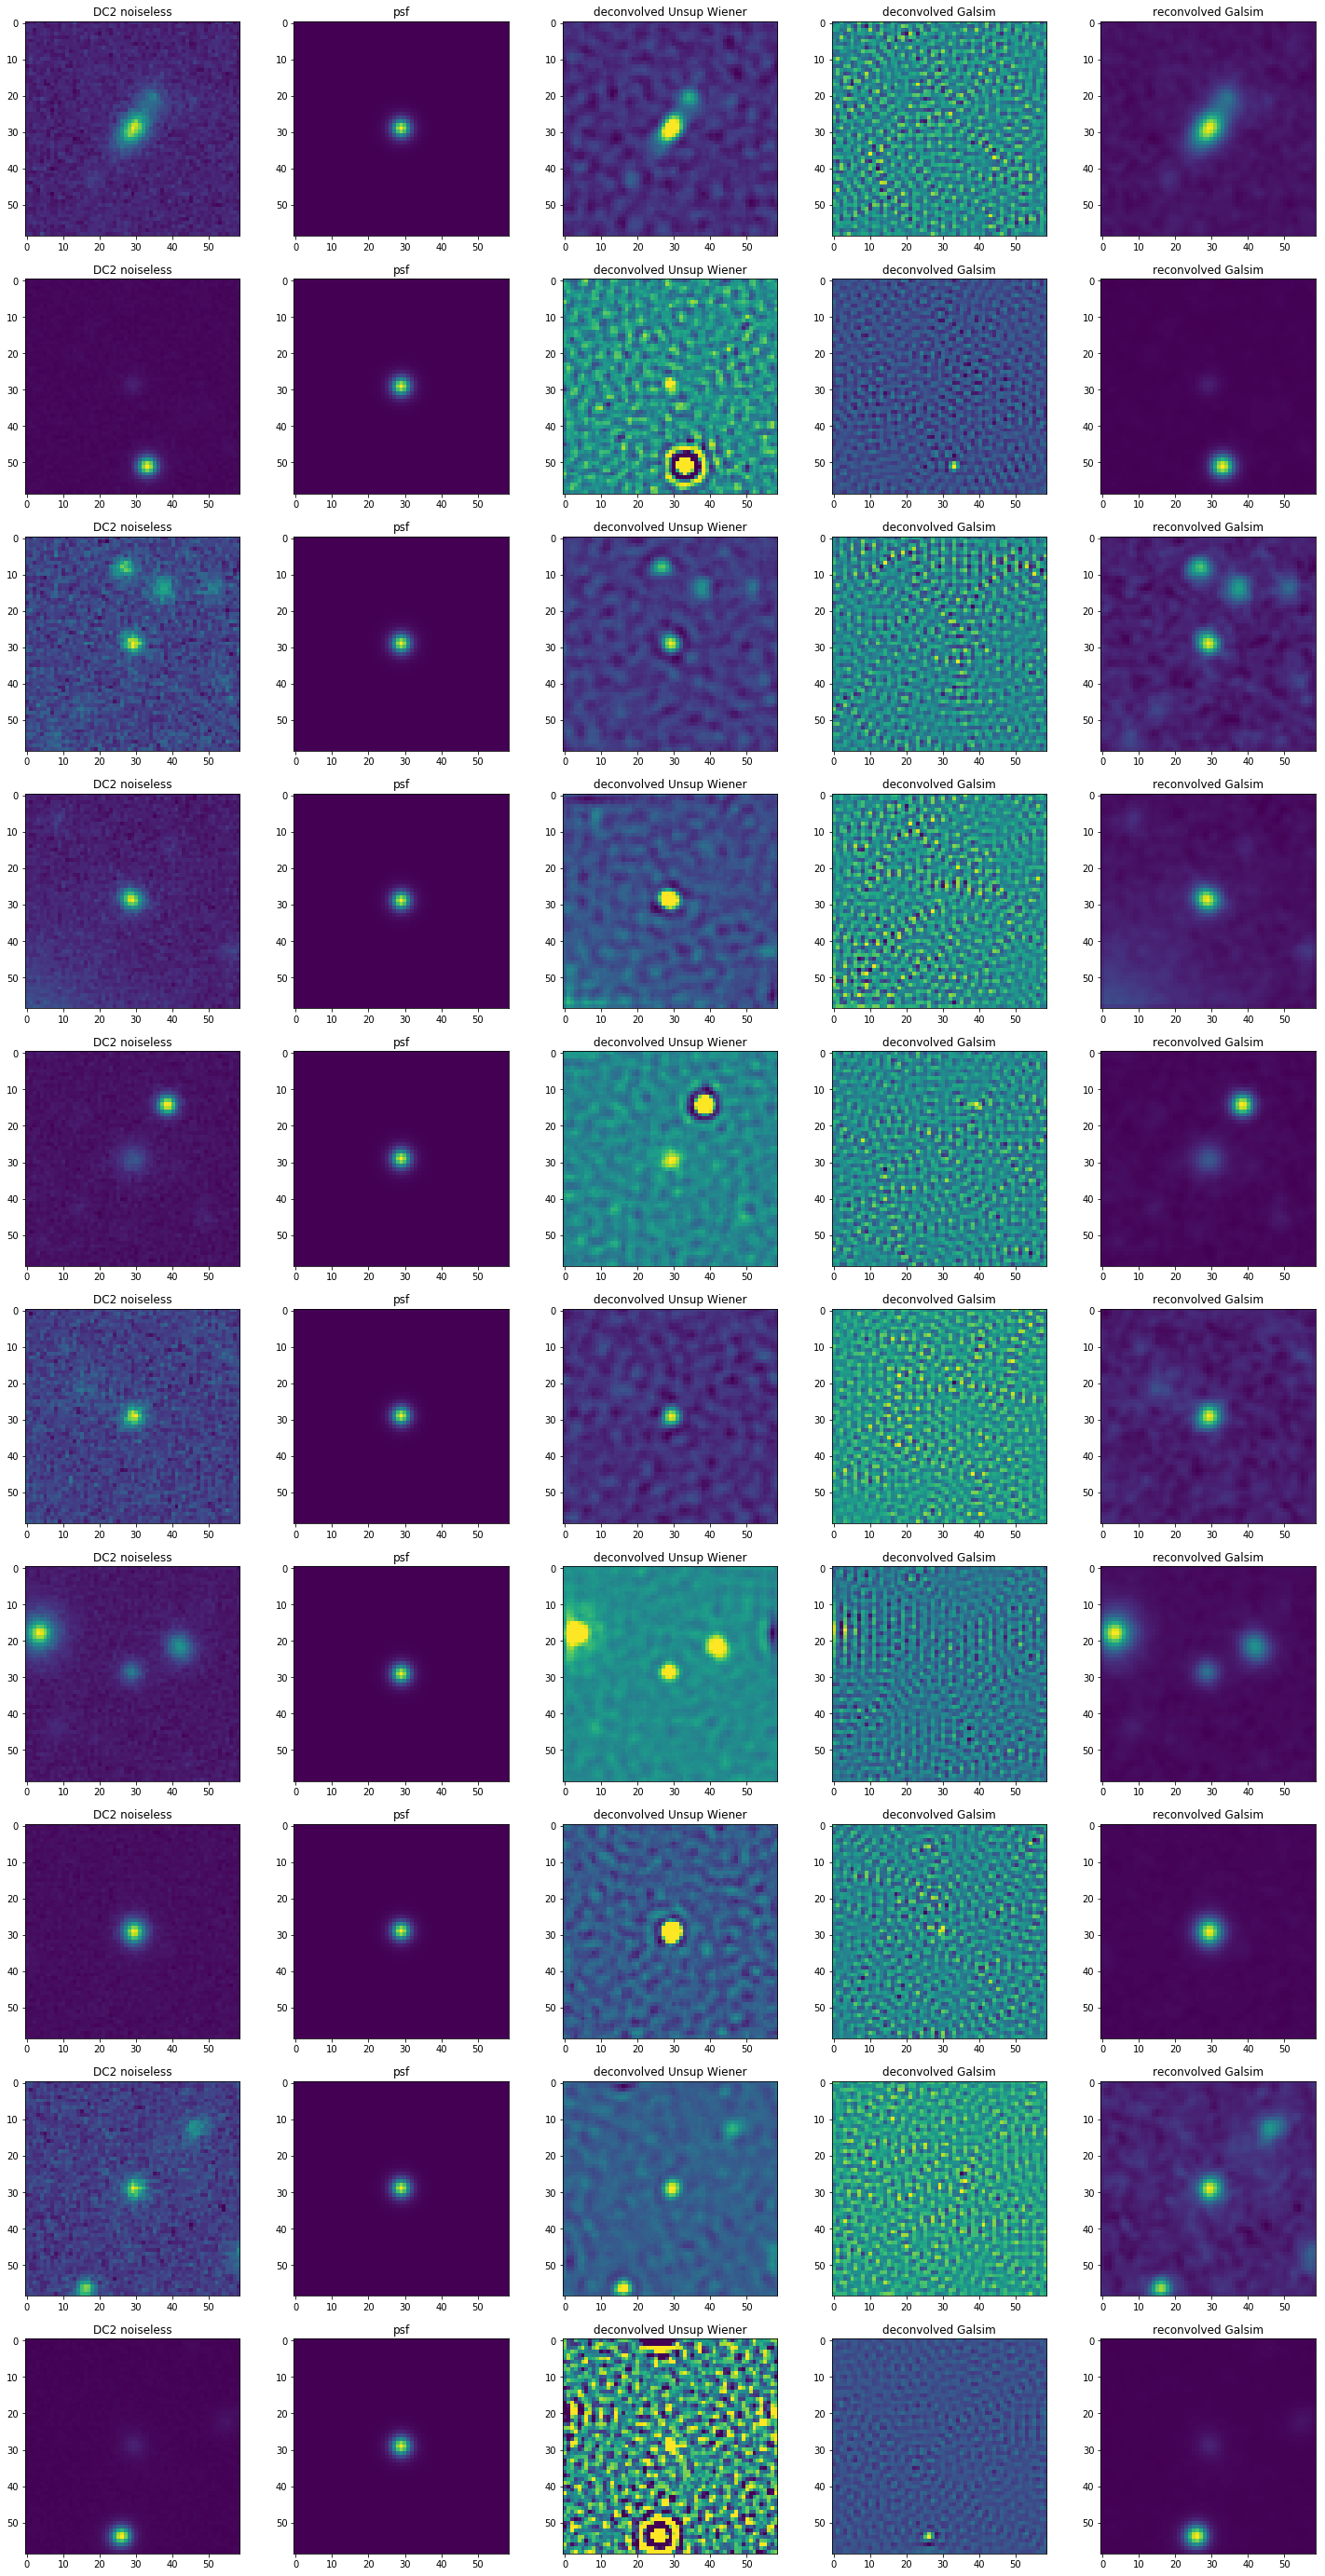

In [28]:
fig, axes = plt.subplots(10,5, figsize = (25,50))

for i in range(10):
    axes[i,0].imshow(images[i,:,:,2])
    axes[i,1].imshow(psf[i,:,:,2])
    axes[i,2].imshow(deconvolved_unsup_wiener[i,:,:,2])
    axes[i,3].imshow(deconvolved_galsim[i,:,:,2])
    axes[i,4].imshow(reconvolved_galsim[i,:,:,2])
    
    axes[i,0].set_title('DC2 noiseless')
    axes[i,1].set_title('psf')
    axes[i,2].set_title('deconvolved Unsup Wiener')
    axes[i,3].set_title('deconvolved Galsim')
    axes[i,4].set_title('reconvolved Galsim')